<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Attempt_at_GPU_Accelerated_Pt3Sn_Spin_DOS_Calculation_with_Kwant_%2B_CuPy_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [1]:
"""This script initializes Conda in the Colab environment."""

!pip install -q condacolab
import condacolab
condacolab.install()

"""This script installs the target scientific libraries via Conda and uv."""

# Control Knobs
CONDA_PACKAGES = [
    "kwant",
    "numpy",
    "scipy",
    "matplotlib"
]

PIP_PACKAGES = [
    "tinyarray>=1.2.4",
    "cupy-cuda12x"
]

!conda install -y -q -c conda-forge {" ".join(CONDA_PACKAGES)}
!python -m pip -q install uv
!uv pip install --system {" ".join(PIP_PACKAGES)}


📢 Announcement 📢
condacolab==0.2 will be released soon! Try it with:

    !pip install -q https://github.com/conda-incubator/condacolab/archive/main.zip
    import condacolab
    condacolab.install()

0.2.x introduces a new installation method based on Pixi, with customizable Python versions.
This may be breaking for your workflow. If that's the case, please report it at
https://github.com/conda-incubator/condacolab and pin your `pip install` command to
condacolab==0.1 as a workaround.

✨🍰✨ Everything looks OK!
Channels:
 - conda-forge
Platform: linux-64
Solving environment: ...working... done

# All requested packages already installed.

Using Python 3.13.13 environment at: /usr/local
Checked 2 packages in 3ms


GPU: NVIDIA L4
GPU memory: 21.84 / 22.03 GiB free

Model summary
  Unit-cell Hilbert dimension: 24
  Symmetry-unique hopping bonds: 27
  Lattice constant: 4.000 A
  Pt SOC parameter: 0.480 eV
  Sn SOC parameter: 0.250 eV
  Reference Dirac energy: +0.140 eV
  Reference R-point SOC scale: 0.720 eV
  v_t_m_s: 5.300e+04 m/s -> 0.0872 eV per unit q
  v_longitudinal_m_s: 5.600e+03 m/s -> 0.0092 eV per unit q
  v_transverse_m_s: 1.900e+04 m/s -> 0.0313 eV per unit q

Hermiticity error: 0.000e+00 eV
Maximum same-k Kramers-pair splitting: 2.503e-06 eV
Kwant/GPU eigenvalue agreement: 2.194e-06 eV


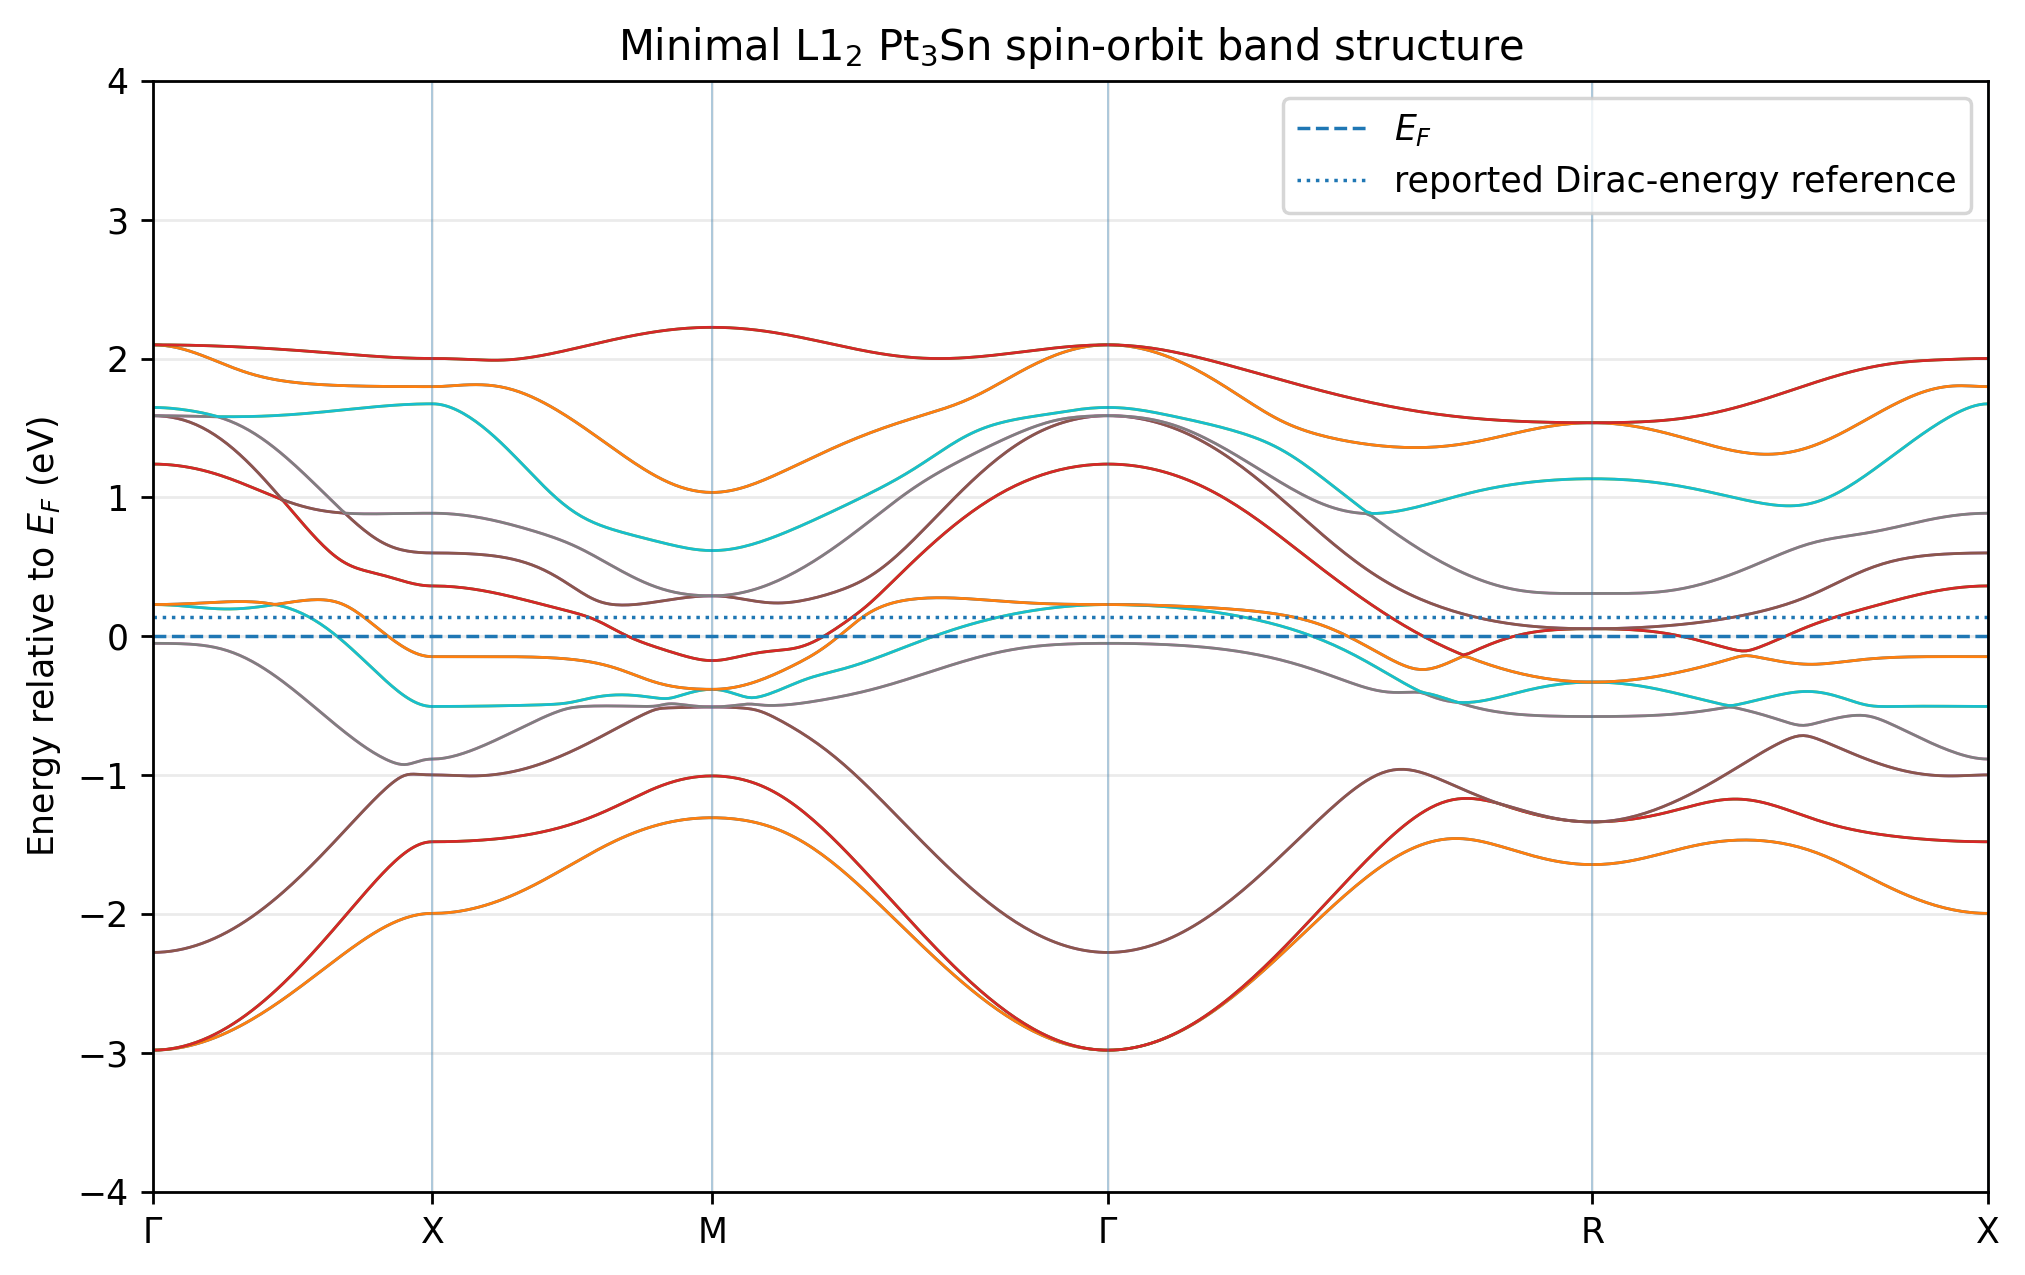

DOS k-points:  17576 / 17576


/tmp/ipykernel_7986/2015217337.py:584: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integrated_states = np.trapz(dos_total, energy)


Integrated DOS inside plotted window: 24.000 states/cell
Maximum bulk spin polarization in resolved DOS: 2.081e-04


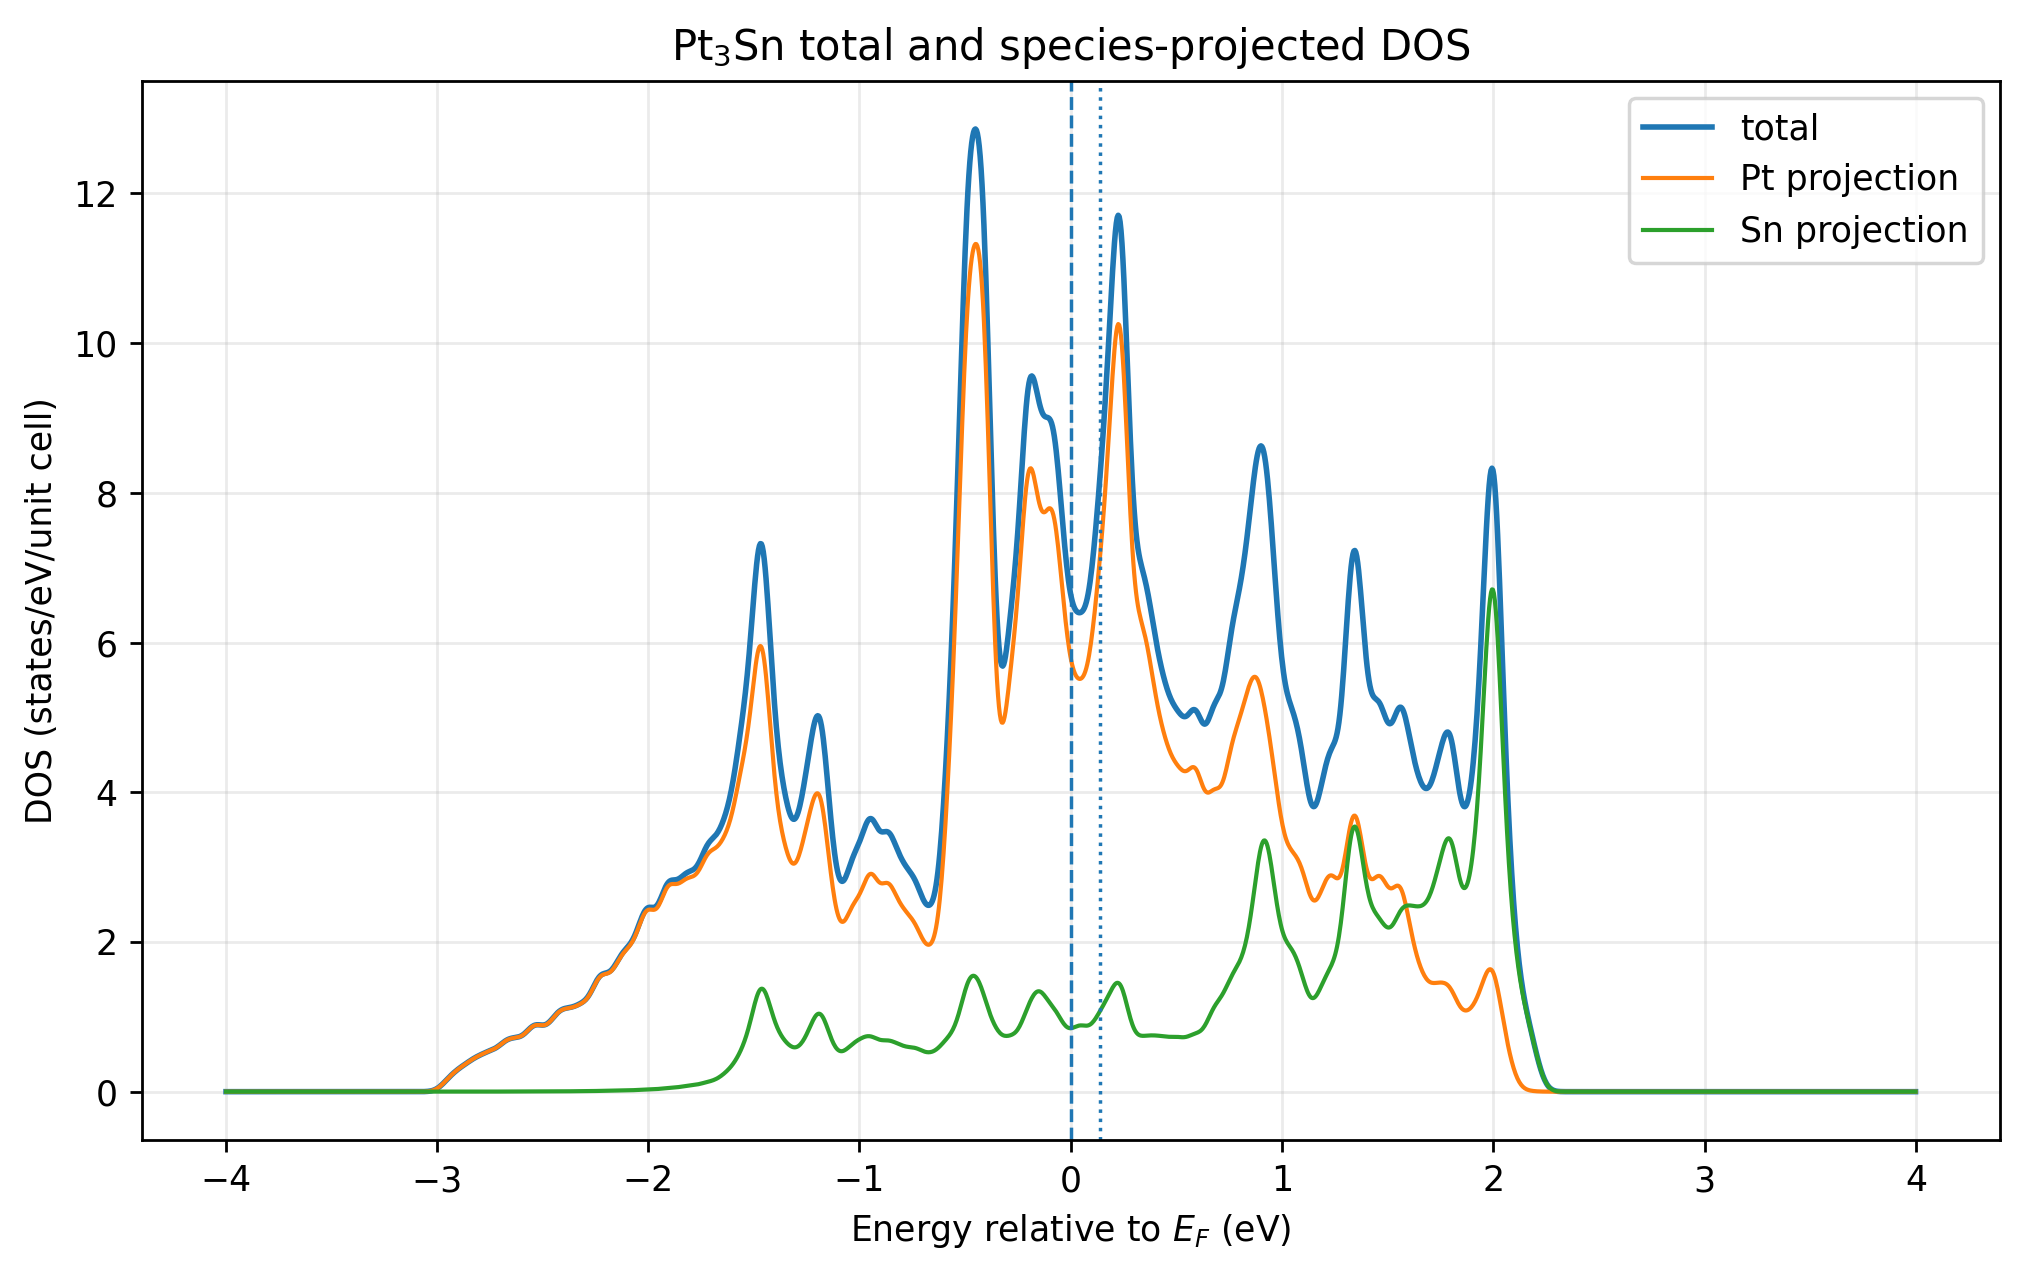

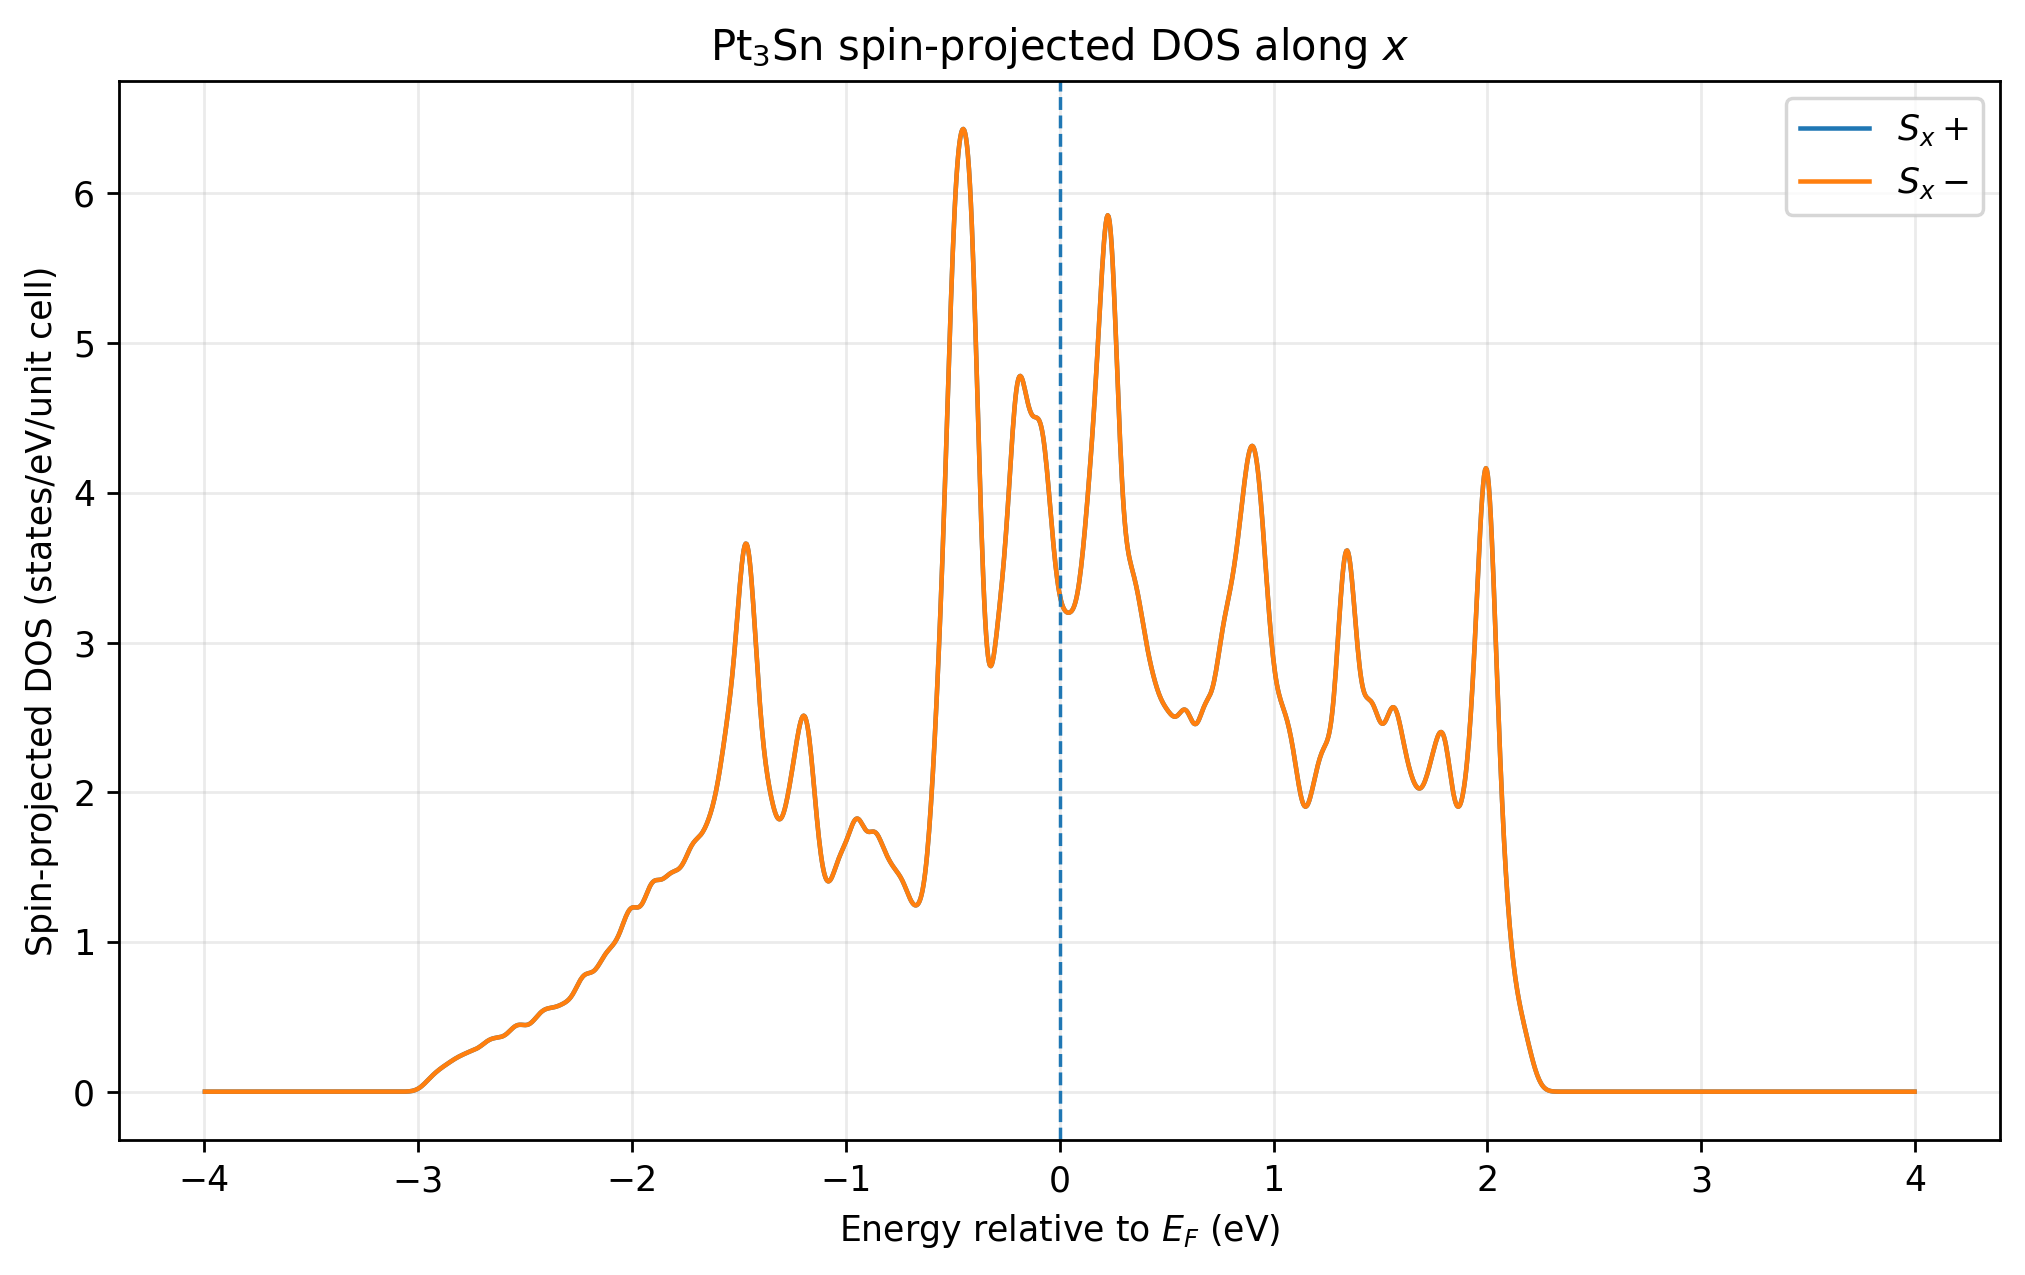

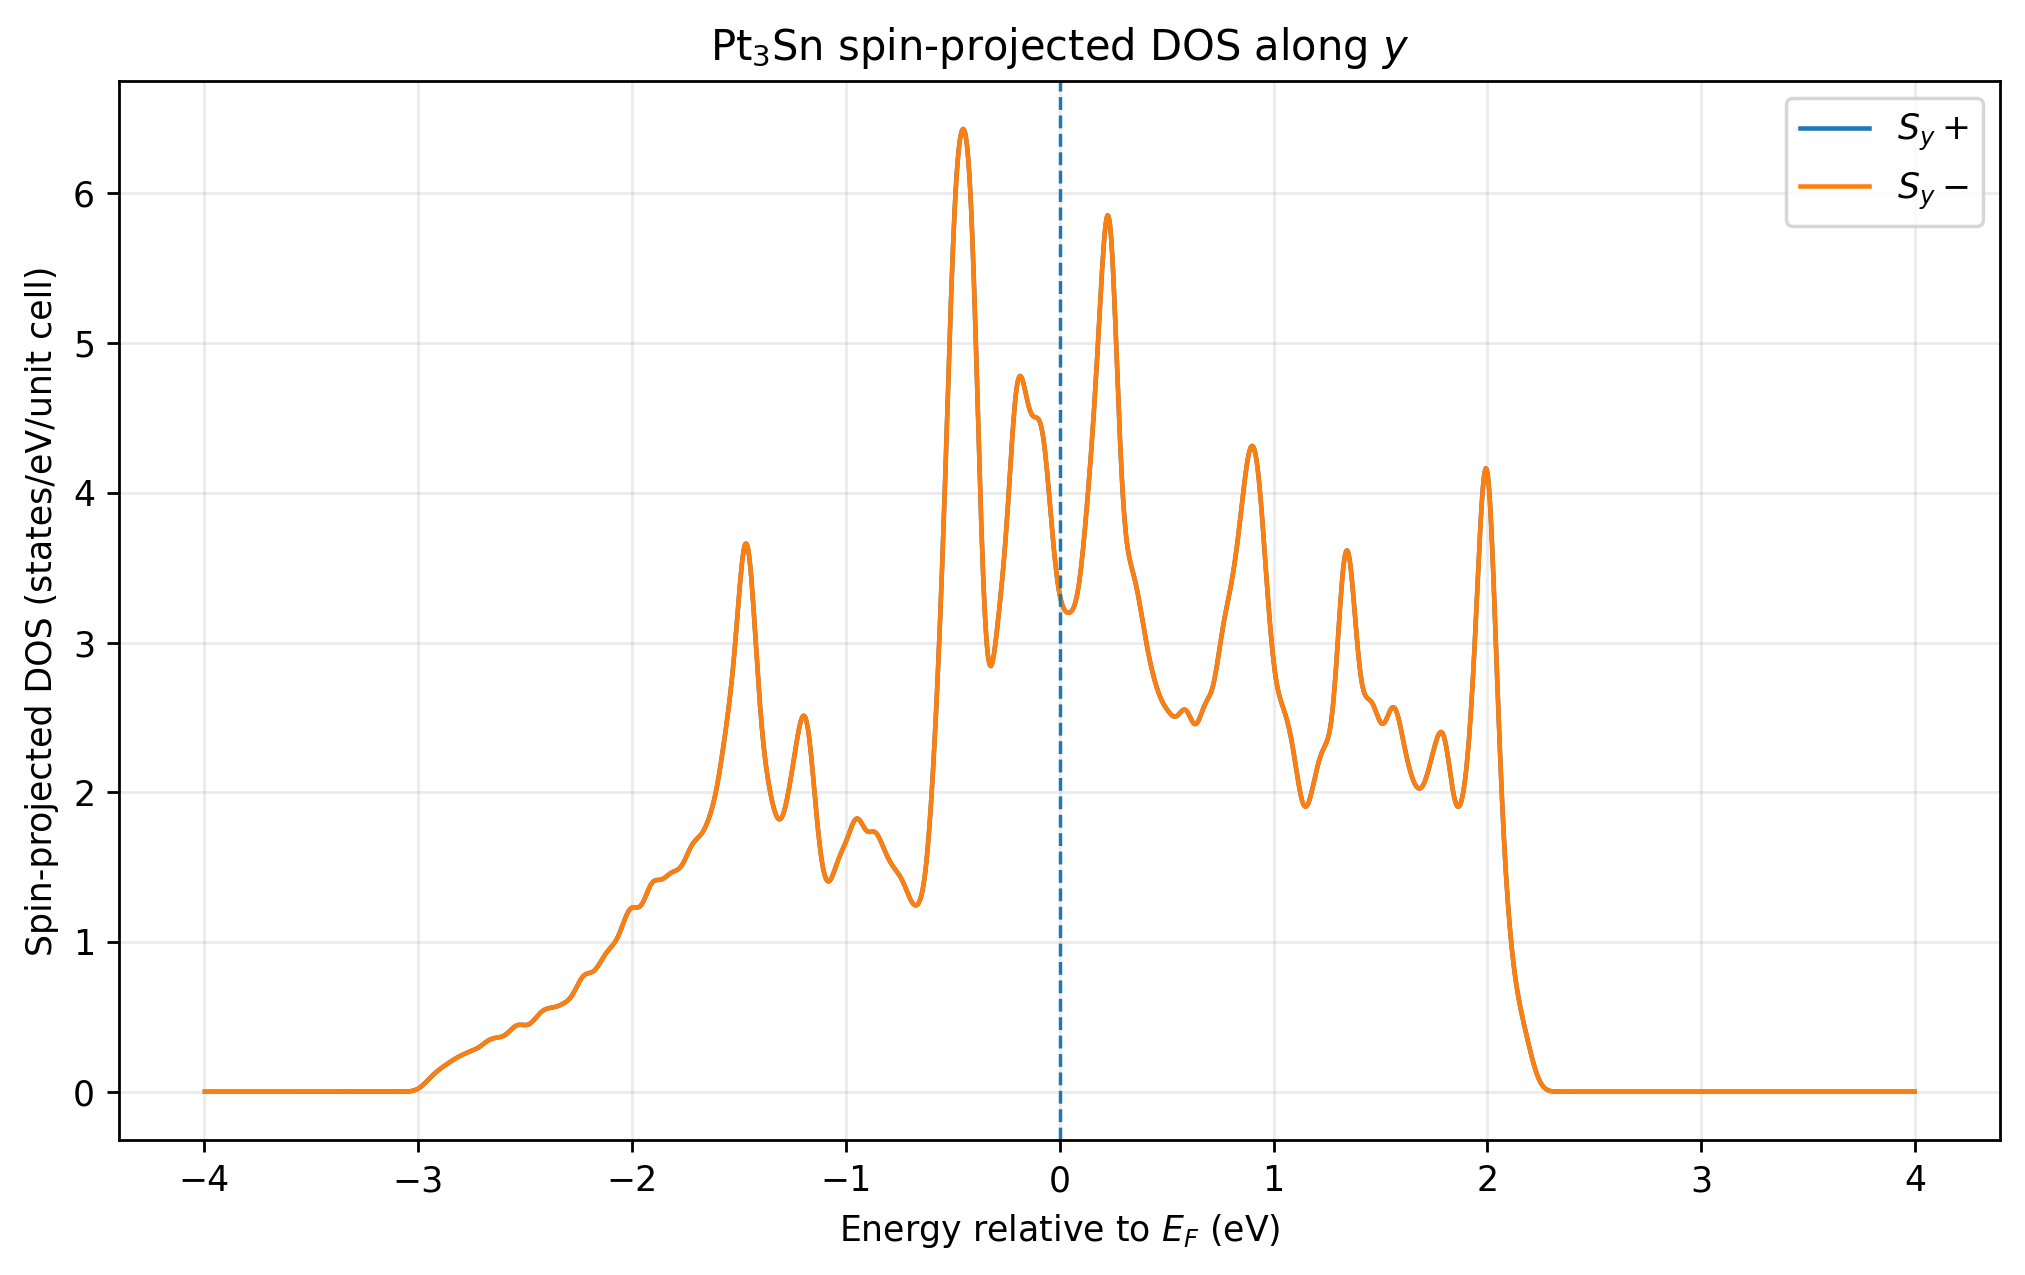

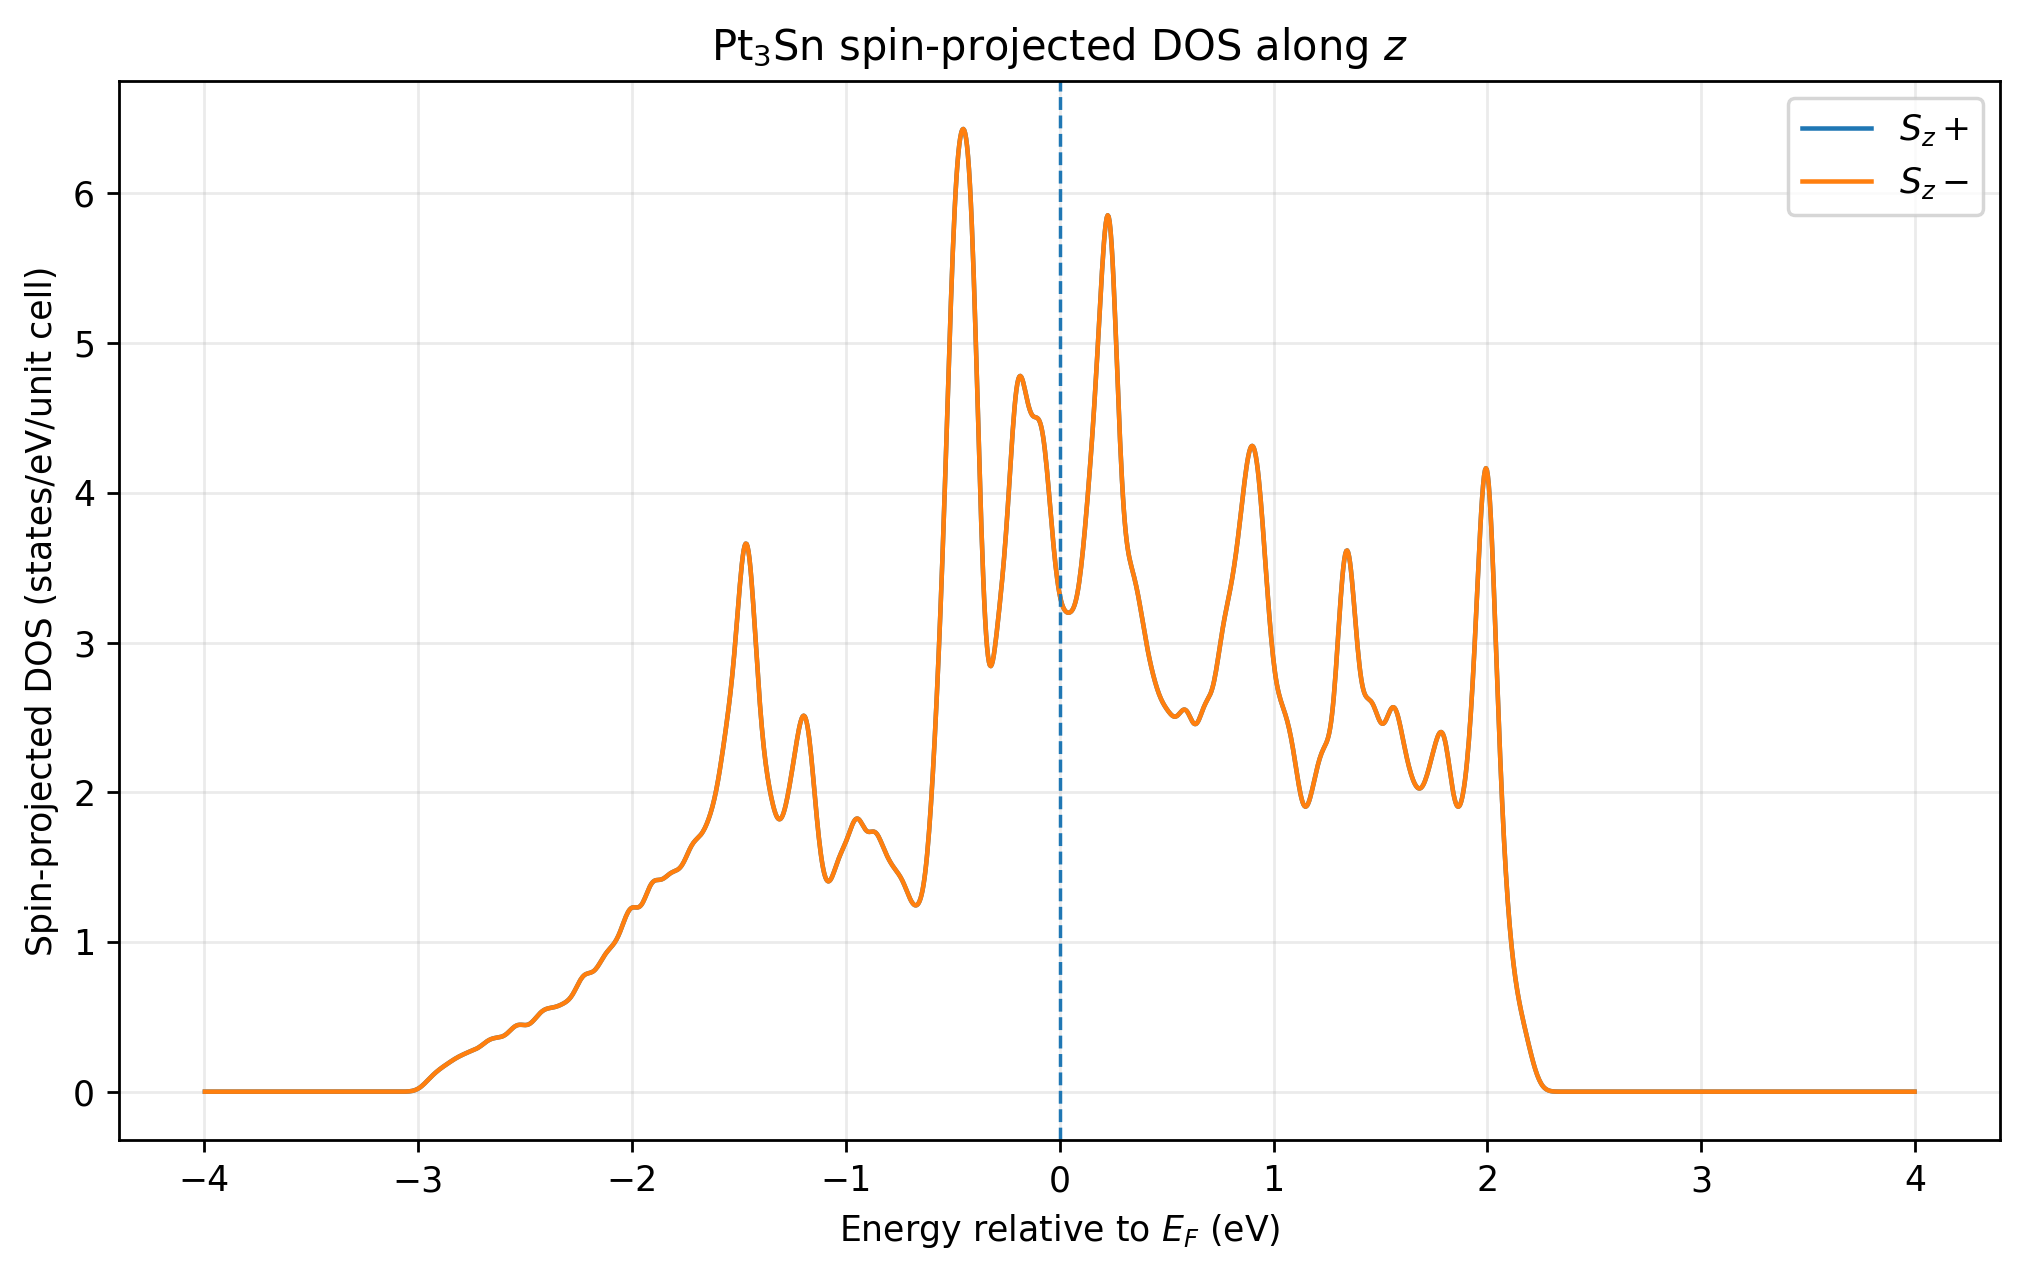

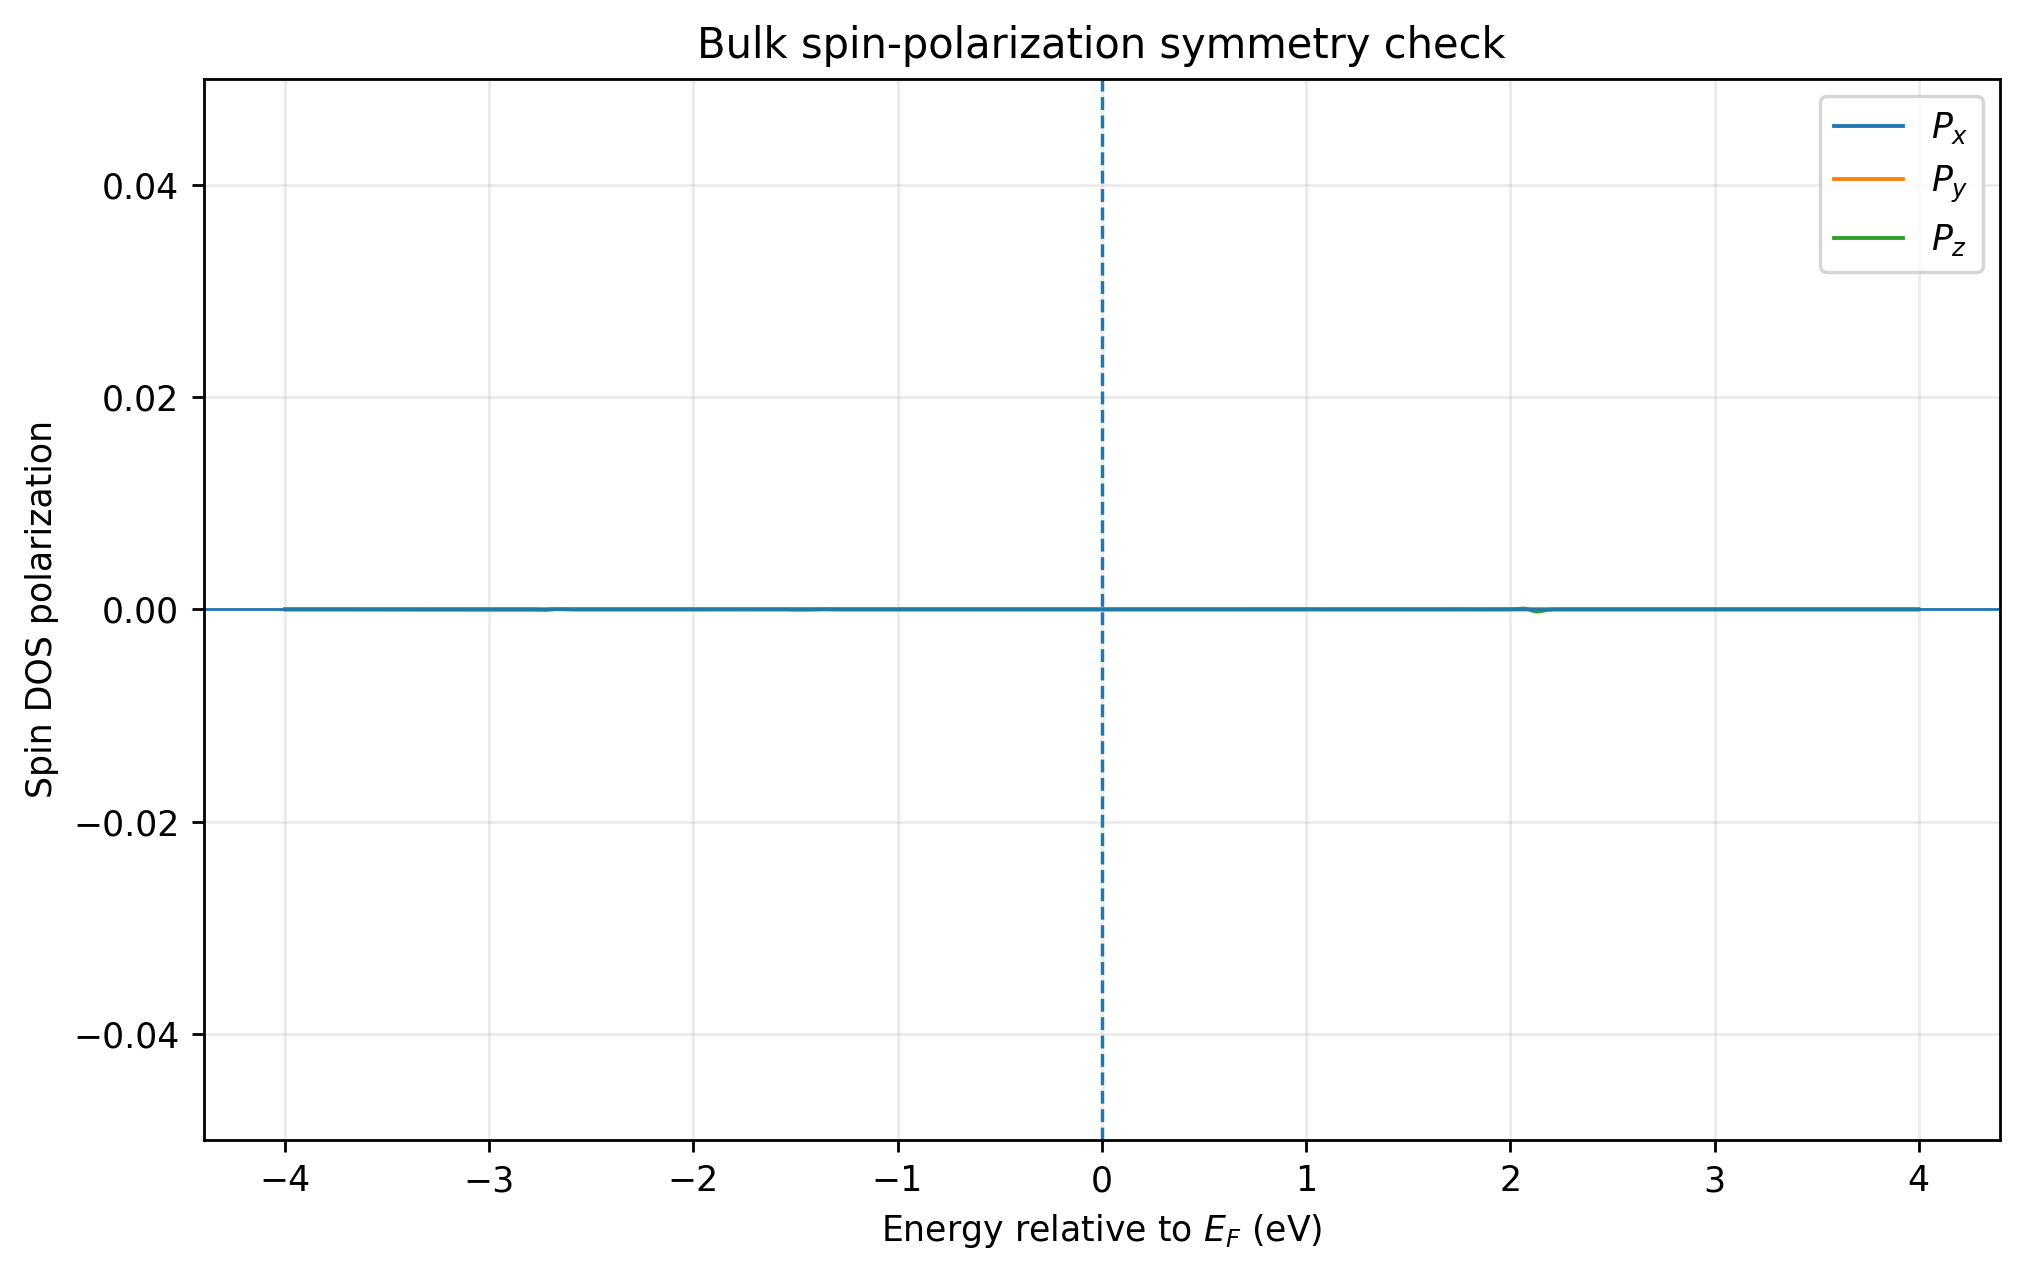

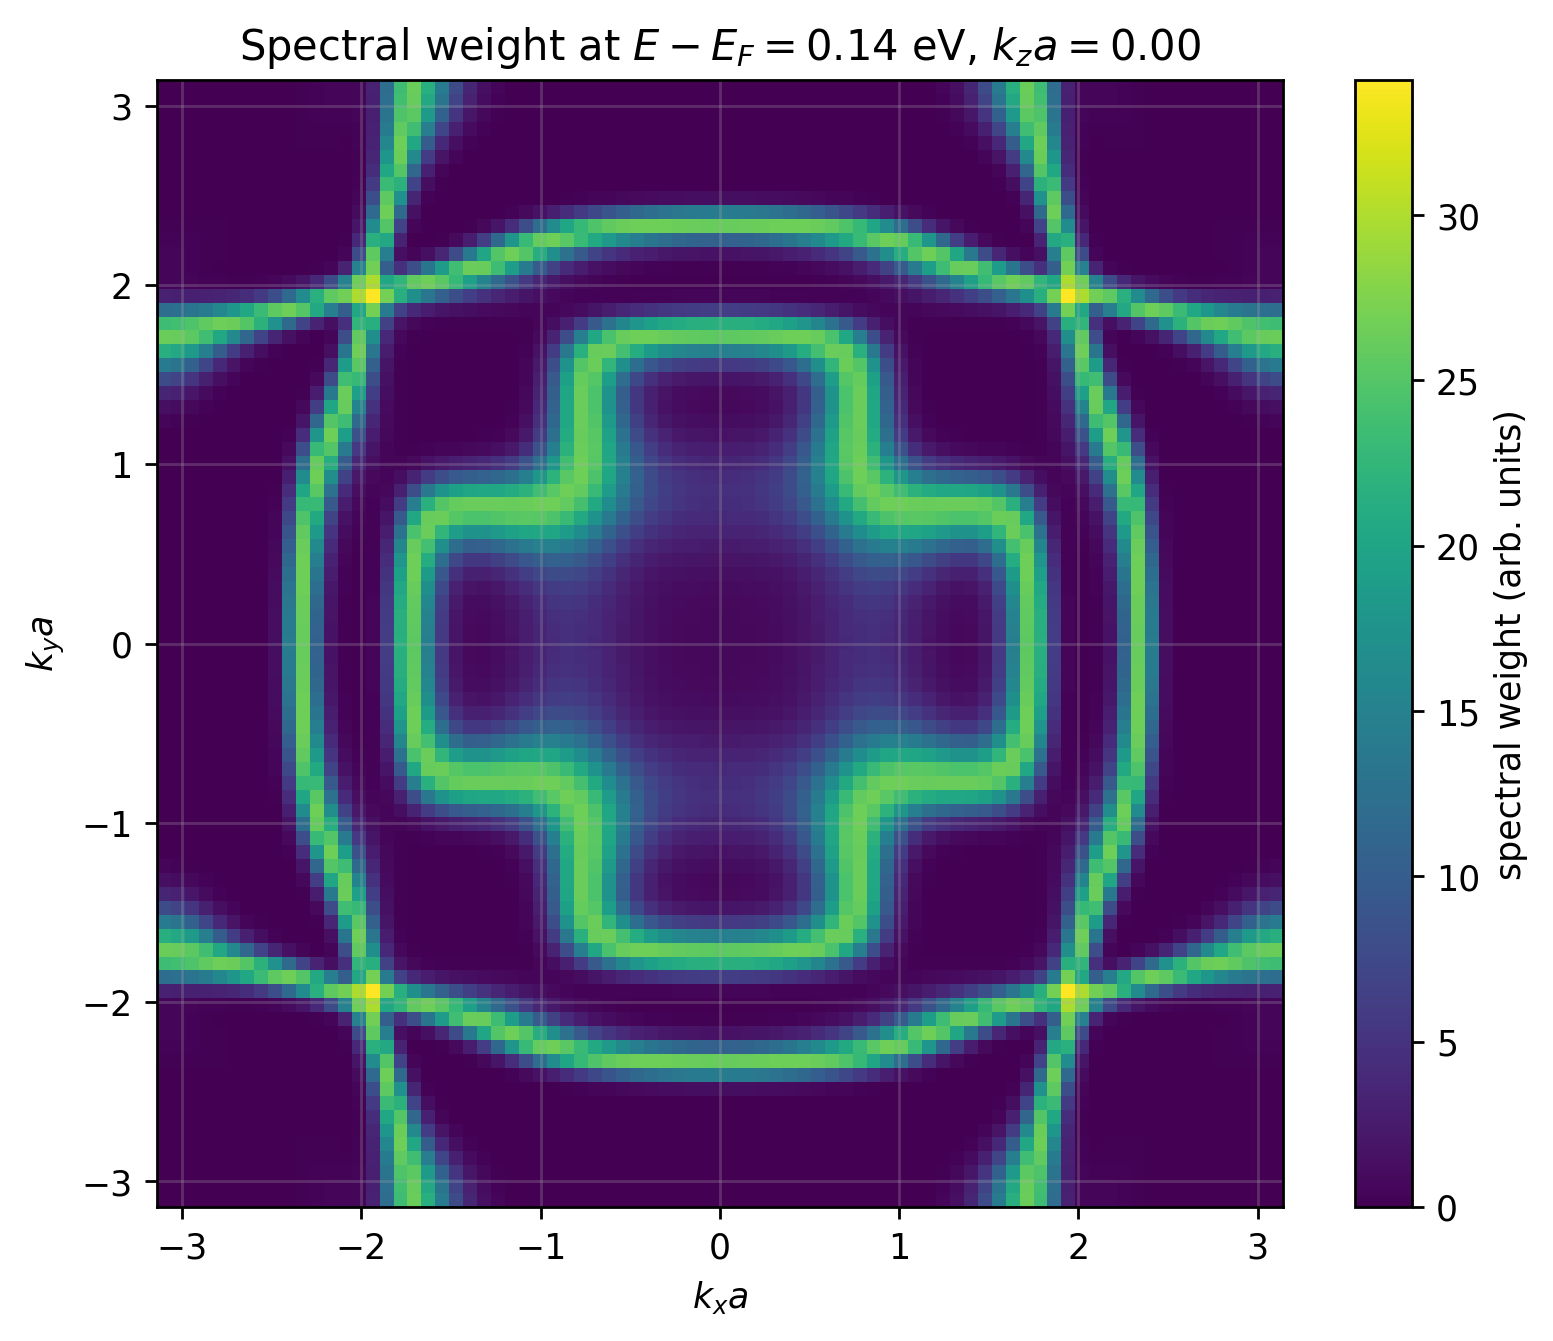

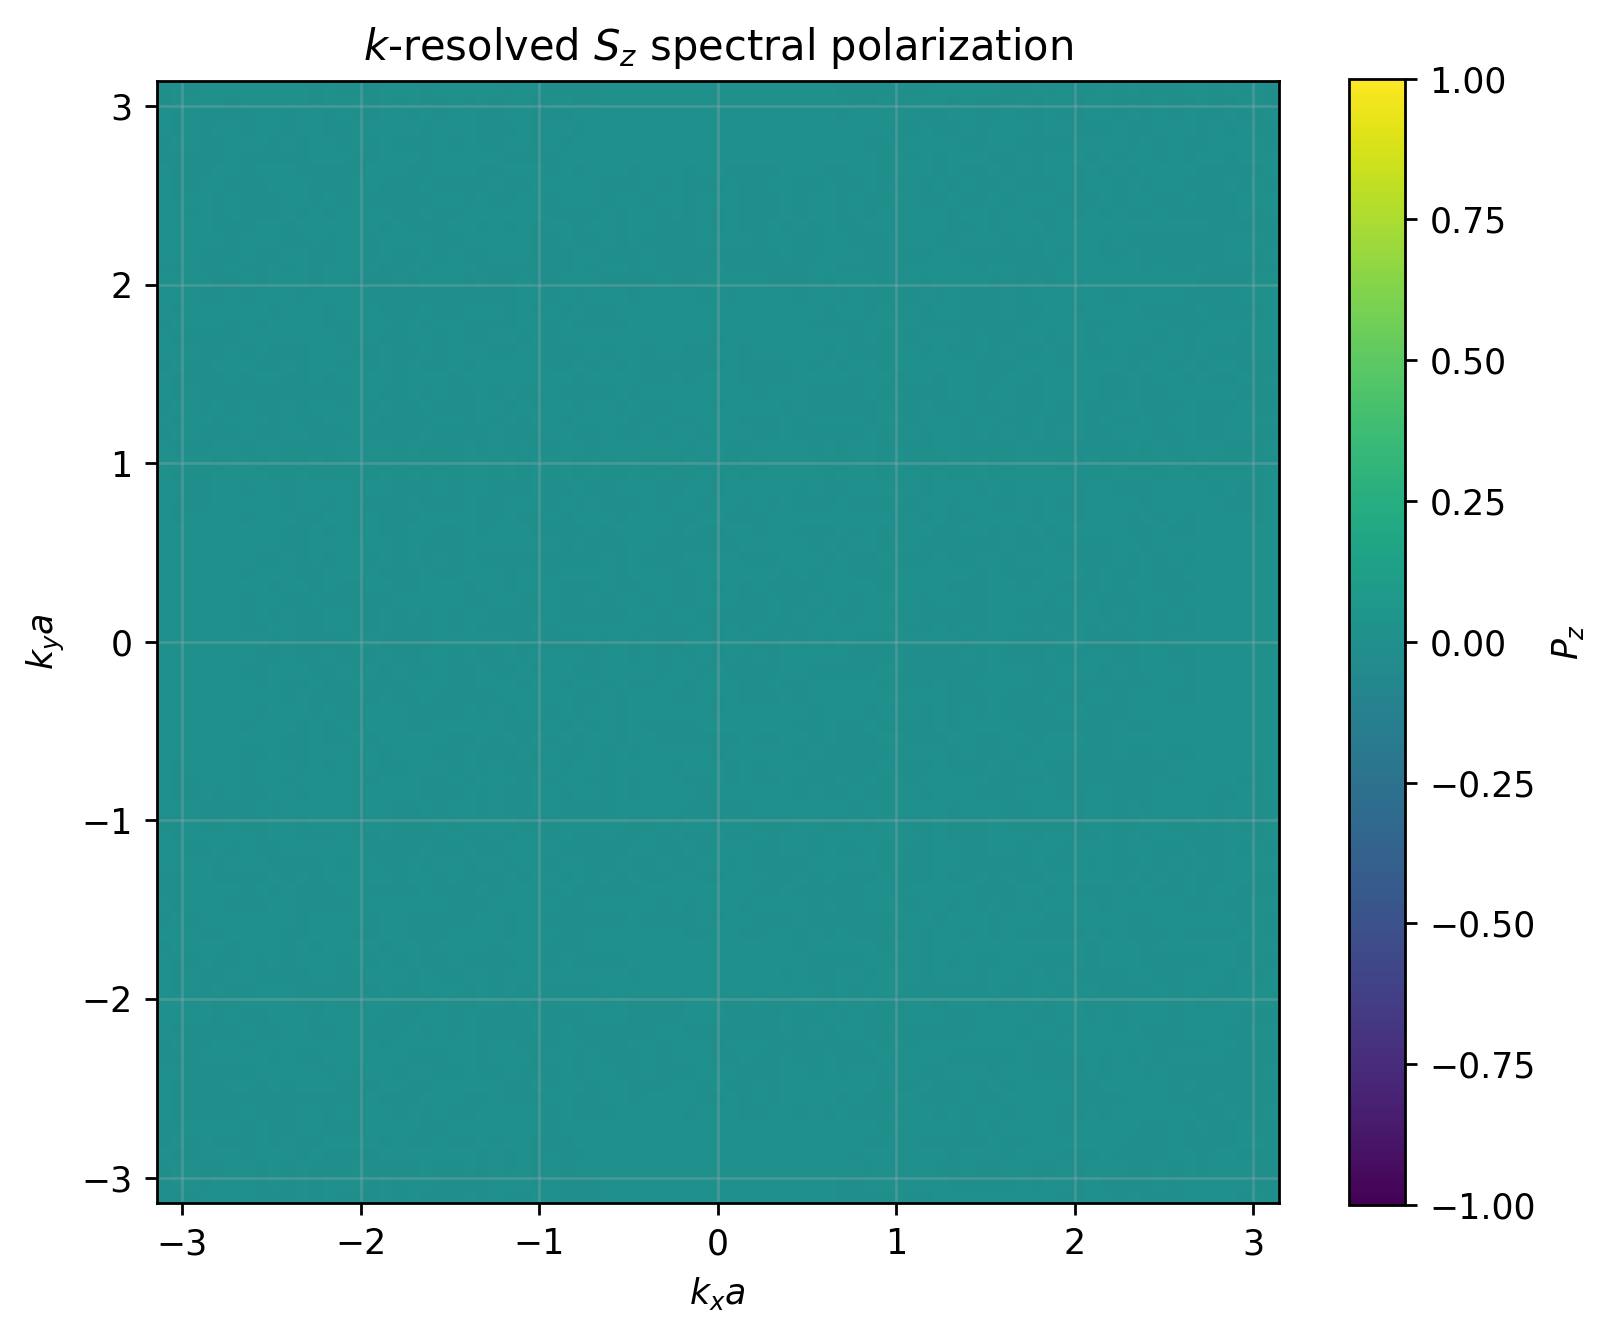

Convergence n= 8: rho(E)=6.594531 states/eV/cell
Convergence n=12: rho(E)=5.557253 states/eV/cell
Convergence n=16: rho(E)=6.955236 states/eV/cell
Convergence n=20: rho(E)=6.667819 states/eV/cell
Convergence n=24: rho(E)=6.479277 states/eV/cell


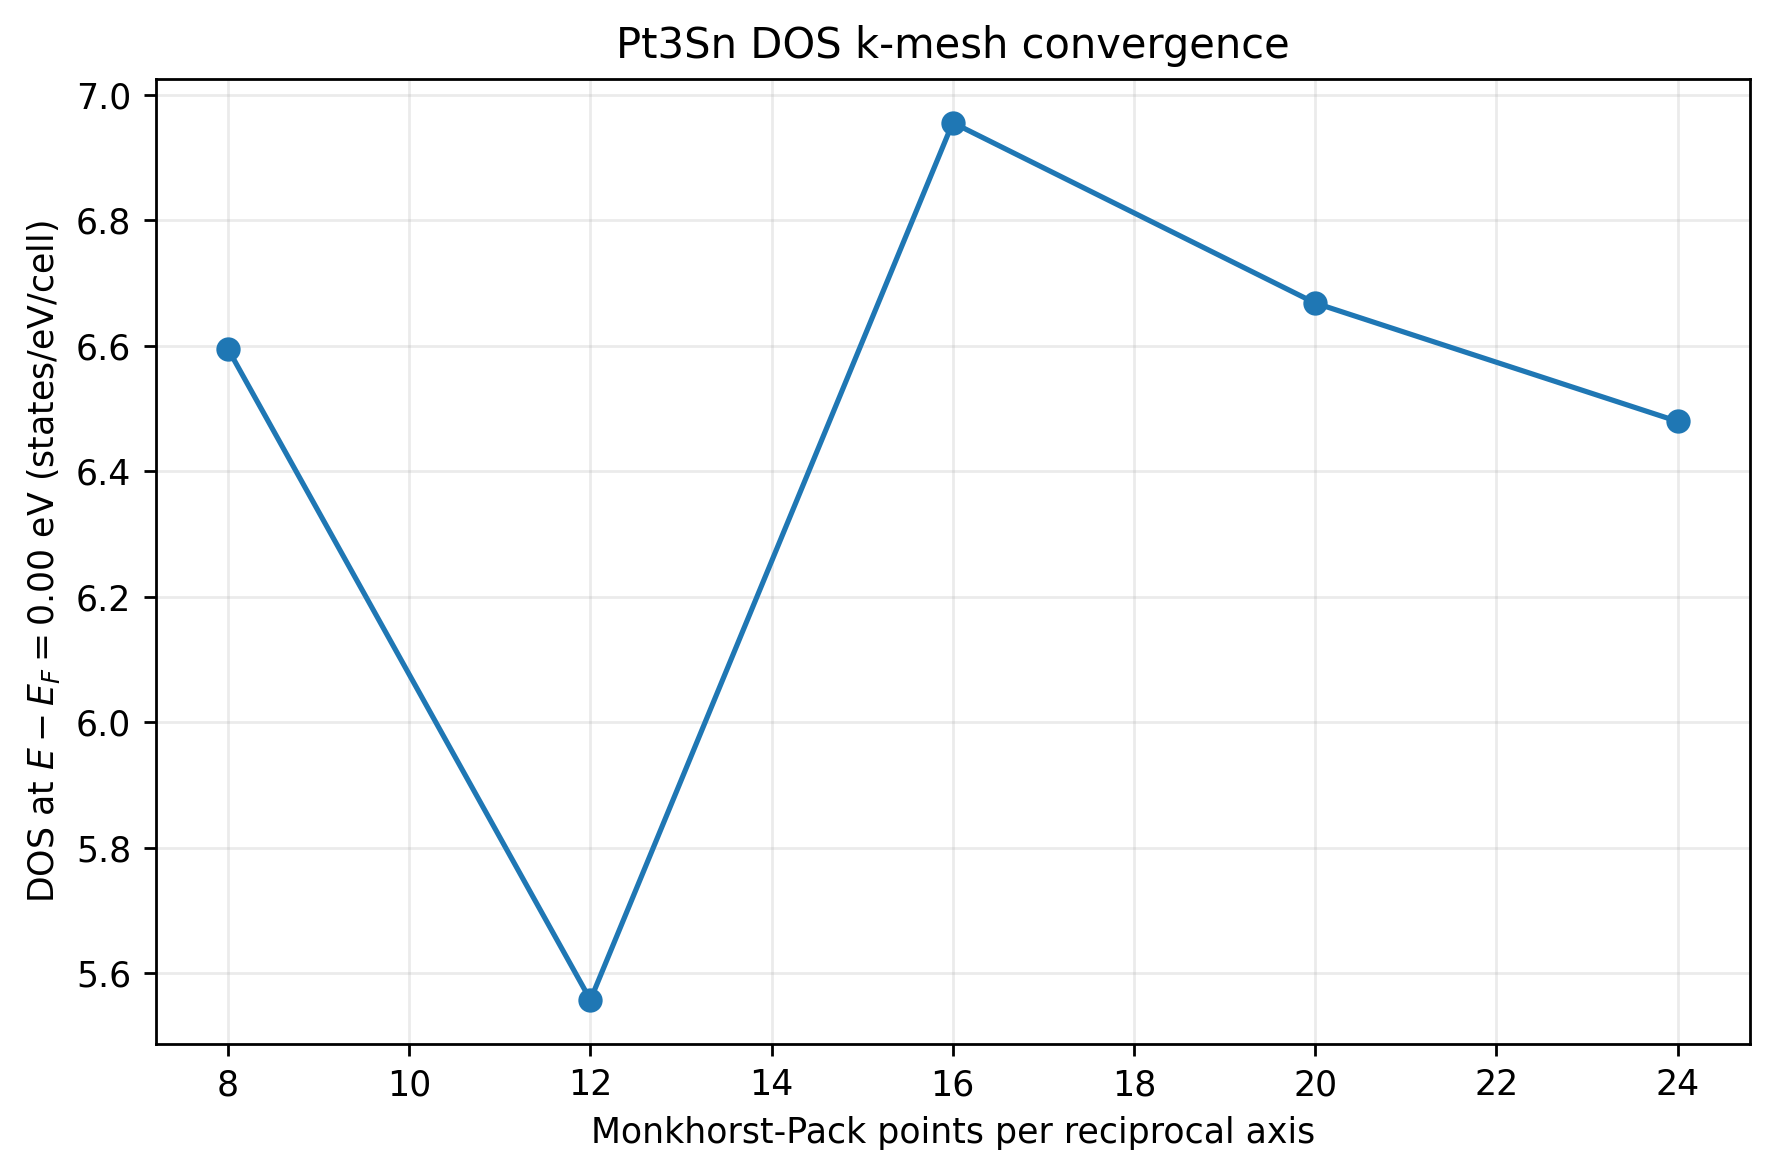


Interpretation
  1. Pt weight should dominate much of the low-energy DOS.
  2. Pristine bulk spin + and spin - DOS should overlap by PT symmetry.
  3. Same-k Kramers splitting should be near numerical precision.
  4. A finite RASHBA_EV intentionally breaks inversion and can expose spin texture.
  5. Quantitative comparison should replace the hand-set hoppings with a SOC Wannier model.


In [2]:
"""GPU-accelerated Pt3Sn spin-resolved density-of-states demonstrator.

The model uses the cubic L1_2 Pt3Sn basis, three effective Pt t2g orbitals,
three Sn p orbitals, atomic spin-orbit coupling, and symmetry-preserving
nearest-neighbor hopping. Kwant constructs and checks the periodic lattice
Hamiltonian. CuPy evaluates Bloch Hamiltonians over dense Brillouin-zone
meshes and calculates bands, total/projected DOS, spin-projected DOS,
Kramers-pair degeneracy, k-resolved spectral spin polarization, and
k-mesh convergence.

This is a calibration-oriented minimal tight-binding model. It is designed
to reproduce symmetry and qualitative Pt-dominated low-energy physics and
to provide a clean path to a DFT/Wannier Hamiltonian. Its hand-set hopping
parameters should not be interpreted as a quantitative Pt3Sn parameter set.
"""

import itertools
import math
from dataclasses import dataclass

import cupy as cp
import kwant
import matplotlib.pyplot as plt
import numpy as np
from cupyx.scipy.ndimage import gaussian_filter1d


# - Control knobs -
A_ANGSTROM = 4.00
PT_SOC_EV = 0.48
SN_SOC_EV = 0.25
PT_ONSITE_EV = -0.20
SN_ONSITE_EV = 0.85
CHEMICAL_POTENTIAL_EV = 0.00

PT_DD_INPLANE_EV = -0.42
PT_DD_NORMAL_EV = -0.10
PT_DD_MIX_EV = 0.055
SN_PP_SIGMA_EV = 0.48
SN_PP_PI_EV = -0.10
PT_SN_SIGMA_EV = 0.34
PT_SN_PI_EV = -0.14

RASHBA_EV = 0.0
EXCHANGE_EV = (0.0, 0.0, 0.0)

K_GRID_N = 26
K_BATCH = 2048
DOS_BINS = 1800
ENERGY_MIN_EV = -4.0
ENERGY_MAX_EV = 4.0
BROADENING_EV = 0.035

BAND_POINTS_PER_SEGMENT = 90
KMAP_N = 81
KMAP_KZ = 0.0
KMAP_ENERGY_EV = 0.14
KMAP_BROADENING_EV = 0.030
CONVERGENCE_GRIDS = (8, 12, 16, 20, 24)
CONVERGENCE_ENERGY_EV = 0.0

GPU_MEMORY_FRACTION = 0.70
GPU_COMPLEX_DTYPE = cp.complex64
GPU_REAL_DTYPE = cp.float32
FIGURE_DPI = 250

REFERENCE = {
    "lattice_a_angstrom": 4.00,
    "dirac_energy_ev": 0.14,
    "soc_split_r_ev": 0.72,
    "v_t_m_s": 5.3e4,
    "v_longitudinal_m_s": 5.6e3,
    "v_transverse_m_s": 1.9e4,
    "spin_hall_conductivity": 4.34e5,
}

plt.rcParams.update(
    {
        "figure.dpi": FIGURE_DPI,
        "savefig.dpi": FIGURE_DPI,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 10,
    }
)


# - Constants and orbital basis -
HBAR_EV_S = 6.582119569e-16
A_M = A_ANGSTROM * 1e-10
SQRT_2_INV = 1.0 / math.sqrt(2.0)
N_ORBITALS_PER_SITE = 3
N_SPIN = 2
NORB_SITE = N_ORBITALS_PER_SITE * N_SPIN
N_SITES_CELL = 4
DIM = N_SITES_CELL * NORB_SITE

BASIS = np.array(
    [
        [0.0, 0.0, 0.0],
        [0.0, 0.5, 0.5],
        [0.5, 0.0, 0.5],
        [0.5, 0.5, 0.0],
    ],
    dtype=float,
)
SITE_LABELS = ("Sn", "Pt_x", "Pt_y", "Pt_z")
IS_PT = np.array([False, True, True, True])

SIGMA_X = np.array([[0.0, 1.0], [1.0, 0.0]], dtype=complex)
SIGMA_Y = np.array([[0.0, -1j], [1j, 0.0]], dtype=complex)
SIGMA_Z = np.array([[1.0, 0.0], [0.0, -1.0]], dtype=complex)
SPIN_MATRICES = 0.5 * np.stack((SIGMA_X, SIGMA_Y, SIGMA_Z))
EYE_2 = np.eye(2, dtype=complex)
EYE_3 = np.eye(3, dtype=complex)
EYE_6 = np.eye(NORB_SITE, dtype=complex)
EYE_DIM = np.eye(DIM, dtype=complex)

# Projected t2g angular momentum in the [d_yz, d_zx, d_xy] basis.
L_T2G_X = np.array(
    [[0, 0, 0], [0, 0, 1j], [0, -1j, 0]], dtype=complex
)
L_T2G_Y = np.array(
    [[0, 0, -1j], [0, 0, 0], [1j, 0, 0]], dtype=complex
)
L_T2G_Z = np.array(
    [[0, 1j, 0], [-1j, 0, 0], [0, 0, 0]], dtype=complex
)

# Ordinary l=1 matrices in the [p_x, p_y, p_z] basis.
L_P_X = np.array(
    [[0, 0, 0], [0, 0, -1j], [0, 1j, 0]], dtype=complex
)
L_P_Y = np.array(
    [[0, 0, 1j], [0, 0, 0], [-1j, 0, 0]], dtype=complex
)
L_P_Z = np.array(
    [[0, -1j, 0], [1j, 0, 0], [0, 0, 0]], dtype=complex
)


@dataclass(frozen=True)
class Bond:
    """One symmetry-unique hopping from site i in cell 0 to site j in cell R."""

    site_i: int
    site_j: int
    cell_r: tuple[int, int, int]
    displacement: np.ndarray
    hopping: np.ndarray


def configure_gpu() -> None:
    """Apply a conservative CuPy memory limit and report the active GPU."""
    pool = cp.get_default_memory_pool()
    try:
        pool.set_limit(fraction=GPU_MEMORY_FRACTION)
    except TypeError:
        pass

    props = cp.cuda.runtime.getDeviceProperties(0)
    name = props["name"]
    if isinstance(name, bytes):
        name = name.decode()
    free_b, total_b = cp.cuda.runtime.memGetInfo()
    print(f"GPU: {name}")
    print(f"GPU memory: {free_b / 2**30:.2f} / {total_b / 2**30:.2f} GiB free")


def atomic_soc(l_matrices: tuple[np.ndarray, ...], strength_ev: float) -> np.ndarray:
    """Return lambda L dot S for a three-orbital spinful local basis."""
    soc = np.zeros((NORB_SITE, NORB_SITE), dtype=complex)
    for l_op, s_op in zip(l_matrices, SPIN_MATRICES):
        soc += strength_ev * np.kron(l_op, s_op)
    return soc


def onsite_matrix(is_pt: bool) -> np.ndarray:
    """Construct one spinful local onsite Hamiltonian."""
    bx, by, bz = EXCHANGE_EV
    exchange = np.kron(
        EYE_3,
        bx * SIGMA_X + by * SIGMA_Y + bz * SIGMA_Z,
    )

    if is_pt:
        soc = atomic_soc(
            (L_T2G_X, L_T2G_Y, L_T2G_Z),
            PT_SOC_EV,
        )
        onsite = PT_ONSITE_EV * EYE_6 + soc + exchange
    else:
        soc = atomic_soc((L_P_X, L_P_Y, L_P_Z), SN_SOC_EV)
        onsite = SN_ONSITE_EV * EYE_6 + soc + exchange

    return onsite - CHEMICAL_POTENTIAL_EV * EYE_6


def pt_pt_orbital_hopping(direction: np.ndarray) -> np.ndarray:
    """Return an even-in-bond-direction effective t2g hopping matrix."""
    n = direction / np.linalg.norm(direction)
    in_plane = 1.0 - n**2
    diagonal = (
        PT_DD_NORMAL_EV
        + (PT_DD_INPLANE_EV - PT_DD_NORMAL_EV) * in_plane
    )
    hopping = np.diag(diagonal)
    mixing = PT_DD_MIX_EV * np.outer(n, n)
    mixing -= np.diag(np.diag(mixing))
    return hopping + mixing


def sn_sn_orbital_hopping(direction: np.ndarray) -> np.ndarray:
    """Return a p-p Slater-Koster-like hopping matrix."""
    n = direction / np.linalg.norm(direction)
    return SN_PP_PI_EV * EYE_3 + (
        SN_PP_SIGMA_EV - SN_PP_PI_EV
    ) * np.outer(n, n)


def pt_sn_orbital_hopping(direction: np.ndarray) -> np.ndarray:
    """Return a minimal direction-dependent Pt-t2g/Sn-p hybridization."""
    n = direction / np.linalg.norm(direction)
    return PT_SN_PI_EV * EYE_3 + (
        PT_SN_SIGMA_EV - PT_SN_PI_EV
    ) * np.outer(n, n)


def rashba_hopping(direction: np.ndarray) -> np.ndarray:
    """Return an optional inversion-breaking Rashba diagnostic term."""
    if RASHBA_EV == 0.0:
        return np.zeros((NORB_SITE, NORB_SITE), dtype=complex)
    n = direction / np.linalg.norm(direction)
    spin_term = n[1] * SIGMA_X - n[0] * SIGMA_Y
    return 1j * RASHBA_EV * np.kron(EYE_3, spin_term)


def hopping_matrix(site_i: int, site_j: int, displacement: np.ndarray) -> np.ndarray:
    """Construct a spinful hopping matrix for one bond."""
    if IS_PT[site_i] and IS_PT[site_j]:
        orbital = pt_pt_orbital_hopping(displacement)
    elif (not IS_PT[site_i]) and (not IS_PT[site_j]):
        orbital = sn_sn_orbital_hopping(displacement)
    else:
        orbital = pt_sn_orbital_hopping(displacement)

    return np.kron(orbital, EYE_2) + rashba_hopping(displacement)


def is_canonical_bond(site_i: int, site_j: int, cell_r: tuple[int, int, int]) -> bool:
    """Keep one orientation from each Hermitian pair."""
    if cell_r > (0, 0, 0):
        return True
    return cell_r == (0, 0, 0) and site_j > site_i


def expected_neighbor_distance(site_i: int, site_j: int) -> float:
    """Return the included neighbor shell distance in lattice units."""
    if IS_PT[site_i] or IS_PT[site_j]:
        return SQRT_2_INV
    return 1.0


def build_bonds() -> list[Bond]:
    """Enumerate the Pt-Sn, Pt-Pt, and Sn-Sn hopping shells."""
    bonds: list[Bond] = []
    for site_i, site_j in itertools.product(range(N_SITES_CELL), repeat=2):
        target = expected_neighbor_distance(site_i, site_j)
        for cell_r in itertools.product((-1, 0, 1), repeat=3):
            if site_i == site_j and cell_r == (0, 0, 0):
                continue
            if not is_canonical_bond(site_i, site_j, cell_r):
                continue

            displacement = BASIS[site_j] + np.asarray(cell_r) - BASIS[site_i]
            distance = np.linalg.norm(displacement)
            if abs(distance - target) > 1e-9:
                continue

            bonds.append(
                Bond(
                    site_i=site_i,
                    site_j=site_j,
                    cell_r=tuple(int(x) for x in cell_r),
                    displacement=displacement,
                    hopping=hopping_matrix(site_i, site_j, displacement),
                )
            )
    return bonds


def build_cell_hamiltonian(bonds: list[Bond]) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return onsite H0, full-cell hopping matrices, and cell translations."""
    h0 = np.zeros((DIM, DIM), dtype=complex)
    for site in range(N_SITES_CELL):
        slc = slice(site * NORB_SITE, (site + 1) * NORB_SITE)
        h0[slc, slc] = onsite_matrix(IS_PT[site])

    matrices = []
    translations = []
    for bond in bonds:
        full = np.zeros((DIM, DIM), dtype=complex)
        i_slc = slice(bond.site_i * NORB_SITE, (bond.site_i + 1) * NORB_SITE)
        j_slc = slice(bond.site_j * NORB_SITE, (bond.site_j + 1) * NORB_SITE)
        full[i_slc, j_slc] = bond.hopping
        matrices.append(full)
        translations.append(np.asarray(bond.cell_r, dtype=float))

    return h0, np.stack(matrices), np.stack(translations)


def build_kwant_system(bonds: list[Bond]):
    """Construct the same periodic model in Kwant and wrap all momenta."""
    lattice = kwant.lattice.general(
        np.eye(3),
        BASIS,
        name="Pt3Sn",
        norbs=[NORB_SITE] * N_SITES_CELL,
    )
    symmetry = kwant.TranslationalSymmetry(*np.eye(3))
    builder = kwant.Builder(symmetry)

    families = lattice.sublattices
    for site, family in enumerate(families):
        builder[family(0, 0, 0)] = onsite_matrix(IS_PT[site])

    for bond in bonds:
        kind = kwant.builder.HoppingKind(
            bond.cell_r,
            families[bond.site_i],
            families[bond.site_j],
        )
        builder[kind] = bond.hopping

    wrapped = kwant.wraparound.wraparound(
        builder,
        coordinate_names="xyz",
    ).finalized()
    return builder, wrapped


def make_global_spin_operator(axis: int) -> np.ndarray:
    """Return Sx, Sy, or Sz acting on every orbital in the unit cell."""
    local = np.kron(EYE_3, SPIN_MATRICES[axis])
    return np.kron(np.eye(N_SITES_CELL), local)


def species_projector(pt: bool) -> np.ndarray:
    """Return the unit-cell projector onto Pt or Sn basis states."""
    projector = np.zeros((DIM, DIM), dtype=complex)
    for site in range(N_SITES_CELL):
        if IS_PT[site] != pt:
            continue
        slc = slice(site * NORB_SITE, (site + 1) * NORB_SITE)
        projector[slc, slc] = EYE_6
    return projector


def monkhorst_pack(n: int) -> np.ndarray:
    """Return a full cubic Monkhorst-Pack mesh in q = k a coordinates."""
    axis = (np.arange(n, dtype=float) + 0.5) * (2.0 * np.pi / n) - np.pi
    qx, qy, qz = np.meshgrid(axis, axis, axis, indexing="ij")
    return np.column_stack((qx.ravel(), qy.ravel(), qz.ravel()))


def high_symmetry_path(points_per_segment: int):
    """Return the simple-cubic Gamma-X-M-Gamma-R-X path."""
    points = {
        r"$\Gamma$": np.array([0.0, 0.0, 0.0]),
        "X": np.array([np.pi, 0.0, 0.0]),
        "M": np.array([np.pi, np.pi, 0.0]),
        "R": np.array([np.pi, np.pi, np.pi]),
    }
    labels = [r"$\Gamma$", "X", "M", r"$\Gamma$", "R", "X"]
    nodes = [
        points[r"$\Gamma$"],
        points["X"],
        points["M"],
        points[r"$\Gamma$"],
        points["R"],
        points["X"],
    ]

    path = []
    ticks = [0]
    for start, stop in zip(nodes[:-1], nodes[1:]):
        t_values = np.linspace(0.0, 1.0, points_per_segment, endpoint=False)
        path.extend(start + t * (stop - start) for t in t_values)
        ticks.append(len(path))
    path.append(nodes[-1])

    path = np.asarray(path)
    distance = np.zeros(len(path))
    distance[1:] = np.cumsum(np.linalg.norm(np.diff(path, axis=0), axis=1))
    tick_positions = [distance[min(i, len(distance) - 1)] for i in ticks]
    return path, distance, tick_positions, labels


def main() -> None:
    """Run the Pt3Sn spin-DOS calculation and produce diagnostic plots."""
    configure_gpu()
    bonds = build_bonds()
    h0_np, bond_matrices_np, translations_np = build_cell_hamiltonian(bonds)
    _, wrapped = build_kwant_system(bonds)

    h0_gpu = cp.asarray(h0_np, dtype=GPU_COMPLEX_DTYPE)
    bond_gpu = cp.asarray(bond_matrices_np, dtype=GPU_COMPLEX_DTYPE)
    translations_gpu = cp.asarray(translations_np, dtype=GPU_REAL_DTYPE)

    spin_ops_gpu = [
        cp.asarray(make_global_spin_operator(i), dtype=GPU_COMPLEX_DTYPE)
        for i in range(3)
    ]
    pt_proj_gpu = cp.asarray(species_projector(True), dtype=GPU_COMPLEX_DTYPE)
    sn_proj_gpu = cp.asarray(species_projector(False), dtype=GPU_COMPLEX_DTYPE)

    def bloch_hamiltonian(q_points: cp.ndarray) -> cp.ndarray:
        """Build a batch of H(q) matrices directly on the GPU."""
        q_points = cp.asarray(q_points, dtype=GPU_REAL_DTYPE)
        phases = cp.exp(1j * (q_points @ translations_gpu.T))
        forward = cp.einsum("bn,nij->bij", phases, bond_gpu, optimize=True)
        h_batch = h0_gpu[None, :, :] + forward
        h_batch += cp.conj(cp.swapaxes(forward, 1, 2))
        return h_batch

    def gpu_eigenvalues(q_np: np.ndarray) -> np.ndarray:
        """Return sorted GPU eigenvalues for a CPU q-point array."""
        result = []
        for start in range(0, len(q_np), K_BATCH):
            q_batch = cp.asarray(q_np[start : start + K_BATCH], dtype=GPU_REAL_DTYPE)
            vals = cp.linalg.eigvalsh(bloch_hamiltonian(q_batch))
            result.append(cp.asnumpy(vals))
        return np.vstack(result)

    print("\nModel summary")
    print(f"  Unit-cell Hilbert dimension: {DIM}")
    print(f"  Symmetry-unique hopping bonds: {len(bonds)}")
    print(f"  Lattice constant: {A_ANGSTROM:.3f} A")
    print(f"  Pt SOC parameter: {PT_SOC_EV:.3f} eV")
    print(f"  Sn SOC parameter: {SN_SOC_EV:.3f} eV")
    print(f"  Reference Dirac energy: +{REFERENCE['dirac_energy_ev']:.3f} eV")
    print(f"  Reference R-point SOC scale: {REFERENCE['soc_split_r_ev']:.3f} eV")

    for key in ("v_t_m_s", "v_longitudinal_m_s", "v_transverse_m_s"):
        slope = HBAR_EV_S * REFERENCE[key] / A_M
        print(f"  {key}: {REFERENCE[key]:.3e} m/s -> {slope:.4f} eV per unit q")

    q_test = np.array([[0.37 * np.pi, 0.21 * np.pi, 0.43 * np.pi]])
    h_test = bloch_hamiltonian(cp.asarray(q_test))[0]
    herm_error = float(cp.max(cp.abs(h_test - h_test.conj().T)).get())
    vals_test = cp.asnumpy(cp.linalg.eigvalsh(h_test))
    kramers_error = float(np.max(np.abs(vals_test[1::2] - vals_test[0::2])))
    print(f"\nHermiticity error: {herm_error:.3e} eV")
    print(f"Maximum same-k Kramers-pair splitting: {kramers_error:.3e} eV")

    params = {
        "k_x": float(q_test[0, 0]),
        "k_y": float(q_test[0, 1]),
        "k_z": float(q_test[0, 2]),
    }
    kwant_h = wrapped.hamiltonian_submatrix(params=params, sparse=False)
    kwant_vals = np.linalg.eigvalsh(kwant_h)
    direct_vals = vals_test
    direct_vals_minus = gpu_eigenvalues(-q_test)[0]
    err_plus = np.max(np.abs(kwant_vals - direct_vals))
    err_minus = np.max(np.abs(kwant_vals - direct_vals_minus))
    print(f"Kwant/GPU eigenvalue agreement: {min(err_plus, err_minus):.3e} eV")

    # - Band structure -
    path, distance, ticks, labels = high_symmetry_path(BAND_POINTS_PER_SEGMENT)
    band_energies = gpu_eigenvalues(path)

    fig = plt.figure(figsize=(8.2, 5.2))
    ax = fig.add_subplot(111)
    for band in range(DIM):
        ax.plot(distance, band_energies[:, band], linewidth=0.8)
    ax.axhline(0.0, linewidth=1.0, linestyle="--", label=r"$E_F$")
    ax.axhline(
        REFERENCE["dirac_energy_ev"],
        linewidth=1.0,
        linestyle=":",
        label="reported Dirac-energy reference",
    )
    for tick in ticks:
        ax.axvline(tick, linewidth=0.5, alpha=0.35)
    ax.set_xticks(ticks, labels)
    ax.set_xlim(distance[0], distance[-1])
    ax.set_ylim(ENERGY_MIN_EV, ENERGY_MAX_EV)
    ax.set_ylabel(r"Energy relative to $E_F$ (eV)")
    ax.set_title(r"Minimal L1$_2$ Pt$_3$Sn spin-orbit band structure")
    ax.legend(loc="upper right")
    fig.tight_layout()
    plt.show()

    # - Full Brillouin-zone DOS and spin projections -
    q_mesh = monkhorst_pack(K_GRID_N)
    n_k = len(q_mesh)
    edges = cp.linspace(
        ENERGY_MIN_EV,
        ENERGY_MAX_EV,
        DOS_BINS + 1,
        dtype=GPU_REAL_DTYPE,
    )
    bin_width = float((ENERGY_MAX_EV - ENERGY_MIN_EV) / DOS_BINS)
    energy = 0.5 * (cp.asnumpy(edges[:-1]) + cp.asnumpy(edges[1:]))

    hist_total = cp.zeros(DOS_BINS, dtype=GPU_REAL_DTYPE)
    hist_pt = cp.zeros_like(hist_total)
    hist_sn = cp.zeros_like(hist_total)
    hist_spin_plus = [cp.zeros_like(hist_total) for _ in range(3)]
    hist_spin_minus = [cp.zeros_like(hist_total) for _ in range(3)]

    for start in range(0, n_k, K_BATCH):
        stop = min(start + K_BATCH, n_k)
        q_batch = cp.asarray(q_mesh[start:stop], dtype=GPU_REAL_DTYPE)
        evals, evecs = cp.linalg.eigh(bloch_hamiltonian(q_batch))
        evals_flat = evals.ravel()

        hist_total += cp.histogram(evals_flat, bins=edges)[0].astype(GPU_REAL_DTYPE)

        pt_weight = cp.einsum(
            "bin,ij,bjn->bn",
            evecs.conj(),
            pt_proj_gpu,
            evecs,
            optimize=True,
        ).real
        sn_weight = cp.einsum(
            "bin,ij,bjn->bn",
            evecs.conj(),
            sn_proj_gpu,
            evecs,
            optimize=True,
        ).real

        hist_pt += cp.histogram(
            evals_flat,
            bins=edges,
            weights=pt_weight.ravel(),
        )[0].astype(GPU_REAL_DTYPE)
        hist_sn += cp.histogram(
            evals_flat,
            bins=edges,
            weights=sn_weight.ravel(),
        )[0].astype(GPU_REAL_DTYPE)

        for axis, spin_op in enumerate(spin_ops_gpu):
            s_expect = cp.einsum(
                "bin,ij,bjn->bn",
                evecs.conj(),
                spin_op,
                evecs,
                optimize=True,
            ).real
            plus_weight = 0.5 + s_expect
            minus_weight = 0.5 - s_expect
            hist_spin_plus[axis] += cp.histogram(
                evals_flat,
                bins=edges,
                weights=plus_weight.ravel(),
            )[0].astype(GPU_REAL_DTYPE)
            hist_spin_minus[axis] += cp.histogram(
                evals_flat,
                bins=edges,
                weights=minus_weight.ravel(),
            )[0].astype(GPU_REAL_DTYPE)

        print(f"DOS k-points: {stop:>6d} / {n_k}", end="\r")
    print()

    sigma_bins = BROADENING_EV / bin_width

    def smooth_and_normalize(hist: cp.ndarray) -> np.ndarray:
        """Gaussian-broaden one histogram into states/eV/unit cell."""
        smoothed = gaussian_filter1d(hist, sigma=sigma_bins, mode="constant")
        return cp.asnumpy(smoothed) / (n_k * bin_width)

    dos_total = smooth_and_normalize(hist_total)
    dos_pt = smooth_and_normalize(hist_pt)
    dos_sn = smooth_and_normalize(hist_sn)
    spin_plus = [smooth_and_normalize(hist) for hist in hist_spin_plus]
    spin_minus = [smooth_and_normalize(hist) for hist in hist_spin_minus]

    integrated_states = np.trapz(dos_total, energy)
    mask = dos_total > 0.02 * np.max(dos_total)
    polarizations = []
    for plus, minus in zip(spin_plus, spin_minus):
        polarization = (plus - minus) / np.maximum(plus + minus, 1e-10)
        polarizations.append(polarization)

    max_bulk_polarization = max(
        float(np.max(np.abs(pol[mask]))) for pol in polarizations
    )
    print(f"Integrated DOS inside plotted window: {integrated_states:.3f} states/cell")
    print(f"Maximum bulk spin polarization in resolved DOS: {max_bulk_polarization:.3e}")

    fig = plt.figure(figsize=(8.2, 5.2))
    ax = fig.add_subplot(111)
    ax.plot(energy, dos_total, linewidth=1.6, label="total")
    ax.plot(energy, dos_pt, linewidth=1.2, label="Pt projection")
    ax.plot(energy, dos_sn, linewidth=1.2, label="Sn projection")
    ax.axvline(0.0, linewidth=1.0, linestyle="--")
    ax.axvline(REFERENCE["dirac_energy_ev"], linewidth=1.0, linestyle=":")
    ax.set_xlabel(r"Energy relative to $E_F$ (eV)")
    ax.set_ylabel("DOS (states/eV/unit cell)")
    ax.set_title(r"Pt$_3$Sn total and species-projected DOS")
    ax.legend()
    fig.tight_layout()
    plt.show()

    axis_names = ("x", "y", "z")
    for axis, axis_name in enumerate(axis_names):
        fig = plt.figure(figsize=(8.2, 5.2))
        ax = fig.add_subplot(111)
        ax.plot(energy, spin_plus[axis], linewidth=1.3, label=rf"$S_{axis_name}+$")
        ax.plot(energy, spin_minus[axis], linewidth=1.3, label=rf"$S_{axis_name}-$")
        ax.axvline(0.0, linewidth=1.0, linestyle="--")
        ax.set_xlabel(r"Energy relative to $E_F$ (eV)")
        ax.set_ylabel("Spin-projected DOS (states/eV/unit cell)")
        ax.set_title(rf"Pt$_3$Sn spin-projected DOS along ${axis_name}$")
        ax.legend()
        fig.tight_layout()
        plt.show()

    fig = plt.figure(figsize=(8.2, 5.2))
    ax = fig.add_subplot(111)
    for axis_name, polarization in zip(axis_names, polarizations):
        ax.plot(energy, polarization, linewidth=1.1, label=rf"$P_{axis_name}$")
    ax.axhline(0.0, linewidth=0.8)
    ax.axvline(0.0, linewidth=1.0, linestyle="--")
    ax.set_xlabel(r"Energy relative to $E_F$ (eV)")
    ax.set_ylabel("Spin DOS polarization")
    ax.set_ylim(-0.05, 0.05)
    ax.set_title("Bulk spin-polarization symmetry check")
    ax.legend()
    fig.tight_layout()
    plt.show()

    # - k-resolved spectral spin polarization -
    k_axis = np.linspace(-np.pi, np.pi, KMAP_N, endpoint=True)
    kx, ky = np.meshgrid(k_axis, k_axis, indexing="xy")
    q_plane = np.column_stack(
        (
            kx.ravel(),
            ky.ravel(),
            np.full(kx.size, KMAP_KZ),
        )
    )

    spectral = np.zeros(len(q_plane), dtype=float)
    spectral_sz = np.zeros(len(q_plane), dtype=float)
    norm = 1.0 / (KMAP_BROADENING_EV * math.sqrt(2.0 * math.pi))

    for start in range(0, len(q_plane), K_BATCH):
        stop = min(start + K_BATCH, len(q_plane))
        q_batch = cp.asarray(q_plane[start:stop], dtype=GPU_REAL_DTYPE)
        evals, evecs = cp.linalg.eigh(bloch_hamiltonian(q_batch))
        weights = norm * cp.exp(
            -0.5 * ((evals - KMAP_ENERGY_EV) / KMAP_BROADENING_EV) ** 2
        )
        sz_expect = cp.einsum(
            "bin,ij,bjn->bn",
            evecs.conj(),
            spin_ops_gpu[2],
            evecs,
            optimize=True,
        ).real
        spectral[start:stop] = cp.asnumpy(cp.sum(weights, axis=1))
        spectral_sz[start:stop] = cp.asnumpy(cp.sum(weights * sz_expect, axis=1))

    spectral = spectral.reshape(KMAP_N, KMAP_N)
    polarization_z = np.zeros_like(spectral)
    spectral_sz = spectral_sz.reshape(KMAP_N, KMAP_N)
    np.divide(
        2.0 * spectral_sz,
        spectral,
        out=polarization_z,
        where=spectral > 1e-8 * np.max(spectral),
    )

    fig = plt.figure(figsize=(6.6, 5.4))
    ax = fig.add_subplot(111)
    image = ax.imshow(
        spectral,
        origin="lower",
        extent=(-np.pi, np.pi, -np.pi, np.pi),
        aspect="equal",
    )
    ax.set_xlabel(r"$k_x a$")
    ax.set_ylabel(r"$k_y a$")
    ax.set_title(
        rf"Spectral weight at $E-E_F={KMAP_ENERGY_EV:.2f}$ eV, $k_z a={KMAP_KZ:.2f}$"
    )
    fig.colorbar(image, ax=ax, label="spectral weight (arb. units)")
    fig.tight_layout()
    plt.show()

    fig = plt.figure(figsize=(6.6, 5.4))
    ax = fig.add_subplot(111)
    image = ax.imshow(
        polarization_z,
        origin="lower",
        extent=(-np.pi, np.pi, -np.pi, np.pi),
        aspect="equal",
        vmin=-1.0,
        vmax=1.0,
    )
    ax.set_xlabel(r"$k_x a$")
    ax.set_ylabel(r"$k_y a$")
    ax.set_title(r"$k$-resolved $S_z$ spectral polarization")
    fig.colorbar(image, ax=ax, label=r"$P_z$")
    fig.tight_layout()
    plt.show()

    # - k-mesh convergence at one energy -
    convergence_values = []
    for n_grid in CONVERGENCE_GRIDS:
        q_conv = monkhorst_pack(n_grid)
        accumulator = 0.0
        for start in range(0, len(q_conv), K_BATCH):
            q_batch = cp.asarray(q_conv[start : start + K_BATCH], dtype=GPU_REAL_DTYPE)
            evals = cp.linalg.eigvalsh(bloch_hamiltonian(q_batch))
            kernel = cp.exp(
                -0.5
                * ((evals - CONVERGENCE_ENERGY_EV) / BROADENING_EV) ** 2
            )
            accumulator += float(cp.sum(kernel).get())

        rho = accumulator / (
            len(q_conv) * BROADENING_EV * math.sqrt(2.0 * math.pi)
        )
        convergence_values.append(rho)
        print(f"Convergence n={n_grid:2d}: rho(E)={rho:.6f} states/eV/cell")

    convergence_values = np.asarray(convergence_values)
    fig = plt.figure(figsize=(7.2, 4.8))
    ax = fig.add_subplot(111)
    ax.plot(CONVERGENCE_GRIDS, convergence_values, marker="o")
    ax.set_xlabel("Monkhorst-Pack points per reciprocal axis")
    ax.set_ylabel(
        rf"DOS at $E-E_F={CONVERGENCE_ENERGY_EV:.2f}$ eV (states/eV/cell)"
    )
    ax.set_title("Pt3Sn DOS k-mesh convergence")
    fig.tight_layout()
    plt.show()

    print("\nInterpretation")
    print("  1. Pt weight should dominate much of the low-energy DOS.")
    print("  2. Pristine bulk spin + and spin - DOS should overlap by PT symmetry.")
    print("  3. Same-k Kramers splitting should be near numerical precision.")
    print("  4. A finite RASHBA_EV intentionally breaks inversion and can expose spin texture.")
    print("  5. Quantitative comparison should replace the hand-set hoppings with a SOC Wannier model.")

if __name__ == "__main__":
    main()